<a href="https://colab.research.google.com/github/JeyasuriyaJ/jeyasuriya-codeboosters-2026/blob/main/Day-2/Day_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import the libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All librariries imported")
print(f"pandas version {pd.__version__}")
print(f"sqlite3 version {sqlite3.version}")

All librariries imported
pandas version 2.2.2
sqlite3 version 2.6.0


In [ ]:
# load the dataset
df = pd.read_csv('student_performance.csv')
print(f"Dataset loaded:{df.shape[0]} students, {df.shape[1]} columns")
print(f"Columns:{df.columns.tolist()}")
print("\n First 3 rows:")
df.head(3)

Dataset loaded:30 students, 13 columns
Columns:['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

 First 3 rows:


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [ ]:
#  Create SQLite database and load student data

conn = sqlite3.connect('college.db')
cursor = conn.cursor()

df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)

cursor.execute("Select count(*) from students")

count = cursor.fetchone()[0]

print(f"Databse 'college.db' created successfully")
print(f"Table 'students' has {count} rows")

Databse 'college.db' created successfully
Table 'students' has 30 rows


In [ ]:
# helper function to run sql queries
def run_query (sql, description = "student"):
  if description:
    print(f"\n{'='*55}")
    print(f" {description}")
    print(f"{'='*55}")

  result = pd.read_sql_query(sql, conn)
  print(result.to_string(index=False))
  return result
print("Helper function 'run_query' defined successfully!")
print("Usage: run_query(sql_string, description_label)")

Helper function 'run_query' defined successfully!
Usage: run_query(sql_string, description_label)


In [ ]:
# sql query - basic select

query1= """
  SELECT student_id, name from students limit 5

  """
result1= run_query(query1, "Query 1: First 5 Students(SELECT+ LIMIT)")


 Query 1: First 5 Students(SELECT+ LIMIT)
 student_id         name
       1001 Aarav Sharma
       1002  Priya Patel
       1003  Rohit Verma
       1004  Sneha Reddy
       1005   Arjun Nair


In [ ]:
# sql query - basic select

query2= """
  SELECT name, department, math_score from students order by math_score desc limit 5

  """
result2= run_query(query2, "Top 5 Math Scorers(ORDER BY DESC+ LIMIT)")


 Top 5 Math Scorers(ORDER BY DESC+ LIMIT)
          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90


In [ ]:
# sql query - basic select

query3= """
  SELECT name, math_score, science_score, programming_score, attendance_percentage from students where department = 'Computer Science'

  """
result3= run_query(query3, "Computer Science Students(WHERE filter)")


 Computer Science Students(WHERE filter)
          name  math_score  science_score  programming_score  attendance_percentage
  Aarav Sharma          85             78                 91                     92
   Priya Patel          76             82                 79                     87
    Arjun Nair          92             88                 95                     90
   Divya Singh          88             91                 93                     96
    Ananya Das          95             89                 97                     98
    Suresh Rao          83             86                 88                     88
   Ajay Tiwari          71             69                 76                     75
Swati Kulkarni          90             87                 92                     94
  Nisha Kapoor          79             84                 83                     89
   Tanvi Mehta          93             90                 96                     97
     Amit Bose          86        

In [ ]:
# sql query - basic select

query4= """
  SELECT name from students where city = 'Lucknow'

  """
result4= run_query(query4, "Computer Science Students(WHERE filter)")


 Computer Science Students(WHERE filter)
         name
  Divya Singh
Gaurav Shukla


In [ ]:
# sql query - basic select

query4= """
  SELECT name, department, attendance_percentage from students where department != 'Mechanical' and attendance_percentage > 93 order by attendance_percentage desc
  limit 5
  """
result4= run_query(query4, "High Attendance (>90%) Excluding Civil Dept")


 High Attendance (>90%) Excluding Civil Dept
          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94


In [ ]:
# sql query - basic select

query4= """
  SELECT name, department, attendance_percentage from students where name between 'A' and 'F' order by name
  """
result4= run_query(query4, "Students between A and F")


 Students between A and F
          name       department  attendance_percentage
  Aarav Sharma Computer Science                     92
   Ajay Tiwari Computer Science                     75
Akanksha Yadav Computer Science                     95
     Amit Bose Computer Science                     91
    Ananya Das Computer Science                     98
    Arjun Nair Computer Science                     90
Deepak Chauhan       Mechanical                     77
   Divya Singh Computer Science                     96


In [ ]:
# SQL Query 5 - Group by with aggregate functions

query5 = """
  SELECT
  department, count(*) as num_students,
  round(avg(math_score),2) as avg_math,
  round(avg(science_score),2) as avg_science,
  round(avg(programming_score), 2) as avg_programming,
  round(avg(attendance_percentage),2) as avg_attendance

from students
group by department
order by avg_math desc
"""
result5= run_query(query5, "Group by with aggregate functions")


 Group by with aggregate functions
      department  num_students  avg_math  avg_science  avg_programming  avg_attendance
Computer Science            13     85.62        84.46            89.23           90.69
      Mechanical             6     71.00        76.50            49.33           83.50
     Electronics             6     71.00        74.17            61.50           80.33
           Civil             5     63.40        66.60            40.60           74.60


In [ ]:
# sql query - basic select

query6= """
  SELECT department, round(avg(math_score),2) as avg_math, count(*) as students
  from students
  group by department
  having avg(math_score) > 70
  order by avg_math desc
  """
result6= run_query(query6, "Departments with Avg Math > 70 (HAVING)")


 Departments with Avg Math > 70 (HAVING)
      department  avg_math  students
Computer Science     85.62        13
      Mechanical     71.00         6
     Electronics     71.00         6


In [ ]:
# sql query - gender-wise performance analysis

query7 = """
  SELECT
    gender,
    count(*) AS num_students,
    round(avg(math_score), 2) AS avg_math,
    round(avg(programming_score), 2) AS avg_programming,
    round(avg(attendance_percentage), 2) AS avg_attendance
  FROM students
  GROUP BY gender
  """
result7= run_query(query7, "gender-wise performance analysis")


 gender-wise performance analysis
gender  num_students  avg_math  avg_programming  avg_attendance
Female            15     78.47             70.2           88.53
  Male            15     73.67             65.0           80.47


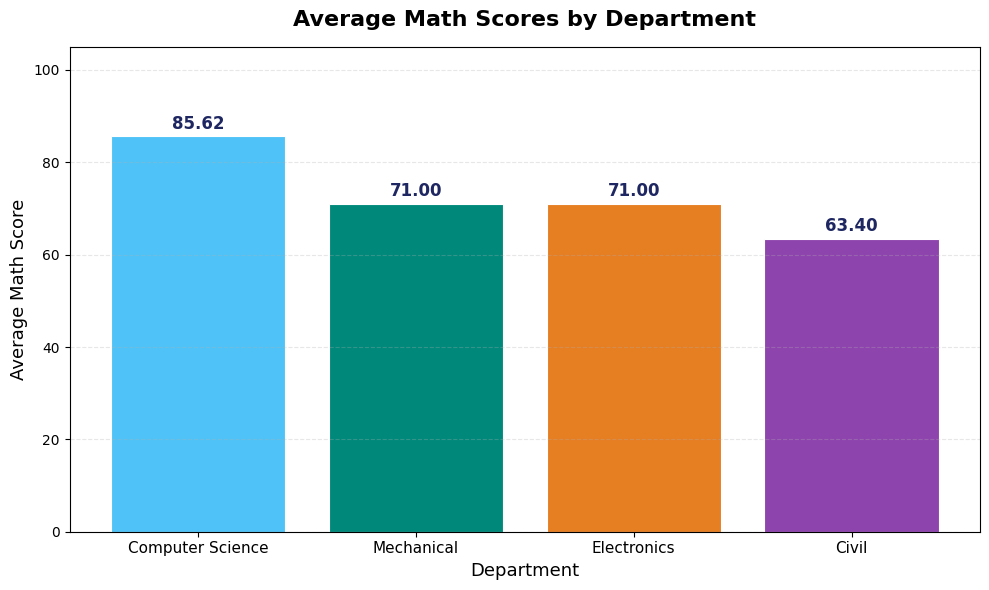

In [20]:
#Get data using SQL
chart1_sql = """
SELECT department, ROUND(AVG(math_score), 2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)


#Create thr bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bar_color = ['#4FC3F7','#00897B','#E67E22','#8E44AD']

bars= ax.bar(
    chart1_data['department'],
    chart1_data['avg_math'],
    color=bar_color,
    edgecolor='white',
    linewidth=0.8
)


for bar in bars:
  height = bar.get_height()
  ax.text(
      bar.get_x() + bar.get_width() / 2,
      height + 0.8,
      f'{height:.2f}',
      ha='center',
      va='bottom',
      fontsize=12,
      fontweight='bold',
      color ='#1E2761'
  )

ax.set_title('Average Math Scores by Department', fontsize=16, fontweight='bold', pad = 15)
ax.set_xlabel('Department', fontsize = 13)
ax.set_ylabel('Average Math Score', fontsize = 13)
ax.set_ylim(0,105)
ax.tick_params(axis='x', labelsize = 11)
ax.grid(axis='y', alpha = 0.3, linestyle ='--')


plt.tight_layout()
plt.show()

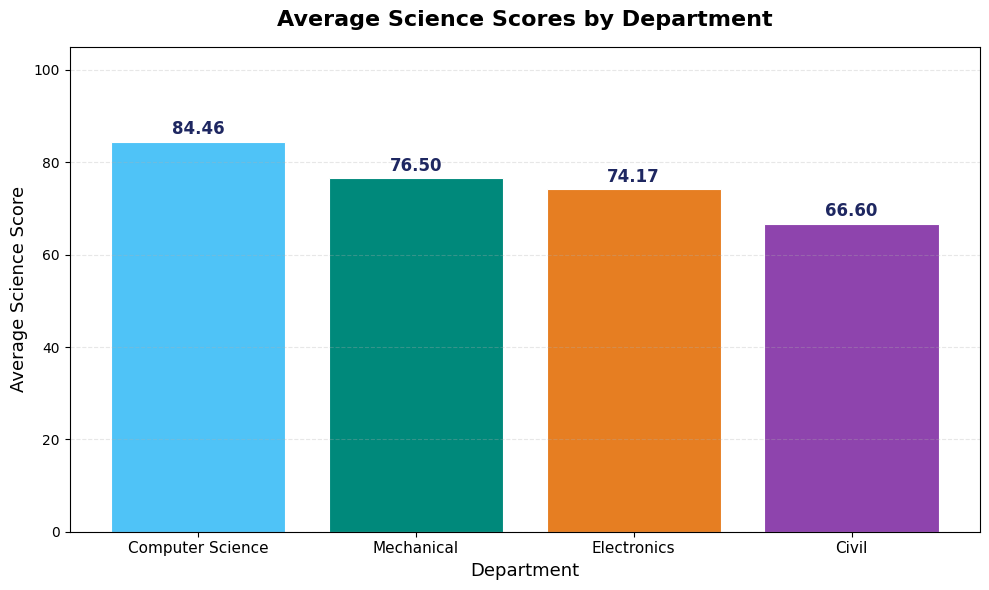

In [21]:
#Get data using SQL
chart1_sql = """
SELECT department, ROUND(AVG(science_score), 2) AS avg_science
FROM students
GROUP BY department
ORDER BY avg_science DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)


#Create thr bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bar_color = ['#4FC3F7','#00897B','#E67E22','#8E44AD']

bars= ax.bar(
    chart1_data['department'],
    chart1_data['avg_science'],
    color=bar_color,
    edgecolor='white',
    linewidth=0.8
)


for bar in bars:
  height = bar.get_height()
  ax.text(
      bar.get_x() + bar.get_width() / 2,
      height + 0.8,
      f'{height:.2f}',
      ha='center',
      va='bottom',
      fontsize=12,
      fontweight='bold',
      color ='#1E2761'
  )

ax.set_title('Average Science Scores by Department', fontsize=16, fontweight='bold', pad = 15)
ax.set_xlabel('Department', fontsize = 13)
ax.set_ylabel('Average Science Score', fontsize = 13)
ax.set_ylim(0,105)
ax.tick_params(axis='x', labelsize = 11)
ax.grid(axis='y', alpha = 0.3, linestyle ='--')


plt.tight_layout()
plt.show()

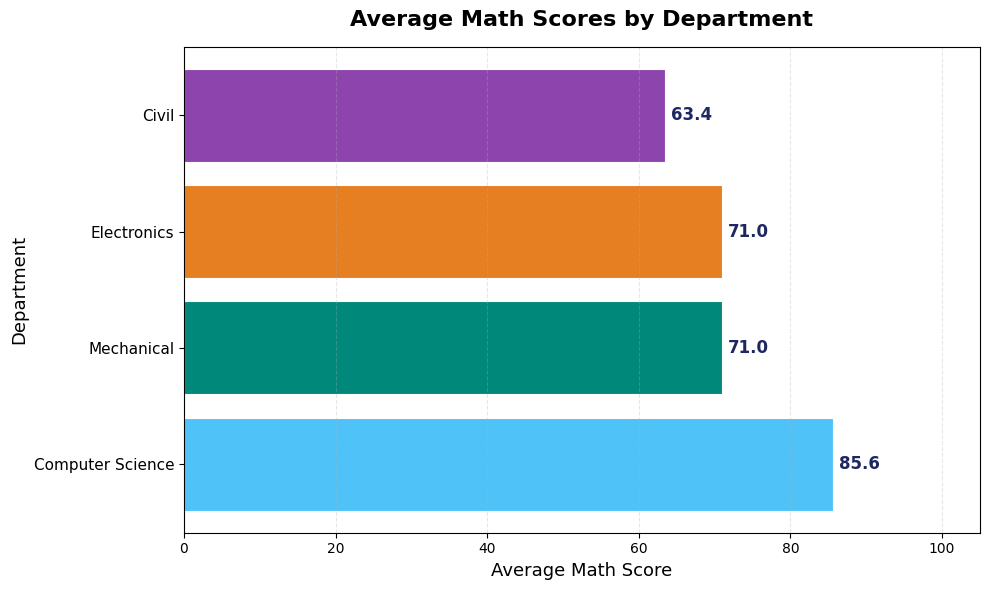

In [22]:
#Get data using SQL
chart1_sql = """
SELECT department, ROUND(AVG(math_score), 2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)


#Create thr bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bar_color = ['#4FC3F7','#00897B','#E67E22','#8E44AD']

bars = ax.barh(chart1_data['department'], chart1_data['avg_math'], color=bar_color, edgecolor = 'white', linewidth = 0.8)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}',
        ha='left',
        va='center',
        fontsize=12,
        fontweight = 'bold',
        color='#1E2761'
    )

ax.set_title('Average Math Scores by Department', fontsize=16, fontweight='bold', pad = 15)
ax.set_ylabel('Department', fontsize = 13)
ax.set_xlabel('Average Math Score', fontsize = 13)
ax.set_xlim(0,105)
ax.tick_params(axis='y', labelsize = 11)
ax.grid(axis='x', alpha = 0.3, linestyle ='--')

plt.tight_layout()
plt.show()